# Nexus Boundary Validation Test Suite

Runnable validation notebook for the Nexus addendum: boundary validation, residence, closure-trace stress, gravity weak-field kernels, hex route memory, Fano/168 structure, primorial wheel structure, BBP random access, SHA-256 transport geometry, and the **90° phase gate**.

Core harness:

$$
\text{claim} \rightarrow \text{operator} \rightarrow \text{domain} \rightarrow \text{trace} \rightarrow \text{null model} \rightarrow \Psi
$$

Trust states:

$$
\oplus = \text{closed/supportable},\qquad
\sim = \text{candidate mapping},\qquad
\Omega = \text{isolated until tested}
$$

90° lock:

$$
R_{90} =
\begin{bmatrix}
0 & -1\\
1 & 0
\end{bmatrix},
\qquad
R_{90}^4 = I,
\qquad
R_{90}v \cdot v = 0.
$$

In [25]:
# ============================================================
# CONFIG
# ============================================================

CONFIG = {
    "RANDOM_SEED": 42,
    "MAKE_PLOTS": True,
    "RUN_HEAVY_TESTS": True,

    "GRID_N": 64,
    "N_TRAJECTORIES": 2000,
    "TRAJECTORY_T": 80,

    "RADIAL_N": 1200,
    "R_MAX": 30.0,

    "PRIME_LIMIT_LIGHT": 200_000,
    "PRIME_LIMIT_HEAVY": 2_000_000,

    "SHA_RANDOM_MESSAGES_LIGHT": 200,
    "SHA_RANDOM_MESSAGES_HEAVY": 1000,
    "SHA_RANDOM_BYTES_MAX": 55,

    "SPARSITY_EPS_PPM": 25.0,
    "SPARSITY_NULL_SAMPLES": 5000,
}

print("Nexus validation config loaded.")
CONFIG

Nexus validation config loaded.


{'RANDOM_SEED': 42,
 'MAKE_PLOTS': True,
 'RUN_HEAVY_TESTS': True,
 'GRID_N': 64,
 'N_TRAJECTORIES': 2000,
 'TRAJECTORY_T': 80,
 'RADIAL_N': 1200,
 'R_MAX': 30.0,
 'PRIME_LIMIT_LIGHT': 200000,
 'PRIME_LIMIT_HEAVY': 2000000,
 'SHA_RANDOM_MESSAGES_LIGHT': 200,
 'SHA_RANDOM_MESSAGES_HEAVY': 1000,
 'SHA_RANDOM_BYTES_MAX': 55,
 'SPARSITY_EPS_PPM': 25.0,
 'SPARSITY_NULL_SAMPLES': 5000}

In [26]:
# ============================================================
# IMPORTS AND TEST REGISTRY
# ============================================================

import math, random, hashlib, struct, itertools, statistics, json, os, sys, time
from pathlib import Path
from dataclasses import dataclass, asdict

try:
    import numpy as np
except Exception as e:
    raise RuntimeError("This notebook requires numpy. Install with: pip install numpy") from e

try:
    import pandas as pd
except Exception:
    pd = None

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

rng = random.Random(CONFIG["RANDOM_SEED"])
np.random.seed(CONFIG["RANDOM_SEED"])

RESULTS = []

def record(name, passed, metrics=None, trust="⊕", notes=""):
    row = {
        "test": name,
        "passed": bool(passed),
        "trust": trust,
        "metrics": metrics or {},
        "notes": notes,
    }
    RESULTS.append(row)
    status = "PASS" if passed else "FAIL"
    print(f"[{status}] {name} | trust={trust}")
    if metrics:
        for k, v in metrics.items():
            print(f"  - {k}: {v}")
    if notes:
        print(f"  notes: {notes}")
    return row

def show_results():
    if pd is not None:
        return pd.DataFrame([
            {
                "test": r["test"],
                "passed": r["passed"],
                "trust": r["trust"],
                **{f"metric:{k}": v for k, v in r["metrics"].items()},
                "notes": r["notes"],
            }
            for r in RESULTS
        ])
    return RESULTS

def relerr(a, b):
    if b == 0:
        return abs(a-b)
    return abs((a-b)/b)

def ppm_error(a, b):
    return 1e6 * (a-b)/b

def gf2_rank(mat):
    # Rank over GF(2). mat must be uint8/bool compatible.
    A = np.array(mat, dtype=np.uint8).copy() & 1
    m, n = A.shape
    rank = 0
    row = 0
    for col in range(n):
        piv = None
        for r in range(row, m):
            if A[r, col]:
                piv = r
                break
        if piv is None:
            continue
        if piv != row:
            A[[row, piv]] = A[[piv, row]]
        for r in range(m):
            if r != row and A[r, col]:
                A[r, :] ^= A[row, :]
        rank += 1
        row += 1
        if row == m:
            break
    return rank

def safe_norm(x):
    x = np.asarray(x, dtype=float)
    return float(np.sqrt(np.sum(x*x)))

OUTDIR = Path("nexus_validation_outputs")
OUTDIR.mkdir(exist_ok=True)
print("Imports ready. Output directory:", OUTDIR.resolve())

Imports ready. Output directory: D:\@User Data\Downloads\nexus_validation_outputs


## Test 1 — Mark 1, $\pi/9$, and the 90° phase gate

Checks:

$$
H=\frac{\pi}{9},
\qquad
\alpha_\Gamma=\frac{H^2}{24}=\frac{\pi^2}{1944}.
$$

The 90° gate is:

$$
\theta_{90}=\frac{\pi}{2}=\frac{9}{2}H.
$$

In [27]:
# ============================================================
# TEST 1: MARK 1 AND 90 DEGREE GATE
# ============================================================

pi = math.pi
H = pi/9
alpha_gamma = H**2 / 24
alpha_expected = pi**2 / 1944

theta90 = pi/2
R90 = np.array([[0.0, -1.0], [1.0, 0.0]])
I2 = np.eye(2)
v = np.array([3.0, 5.0])
Rv = R90 @ v

checks = {
    "H": H,
    "alpha_gamma": alpha_gamma,
    "alpha_expected": alpha_expected,
    "alpha_abs_error": abs(alpha_gamma-alpha_expected),
    "theta90_over_H": theta90/H,
    "R90_fourth_error": float(np.max(np.abs(np.linalg.matrix_power(R90, 4)-I2))),
    "orthogonality_dot": float(np.dot(v, Rv)),
    "norm_before": safe_norm(v),
    "norm_after": safe_norm(Rv),
}

passed = (
    abs(alpha_gamma-alpha_expected) < 1e-15
    and abs(theta90/H - 4.5) < 1e-15
    and checks["R90_fourth_error"] < 1e-15
    and abs(checks["orthogonality_dot"]) < 1e-15
    and abs(checks["norm_before"]-checks["norm_after"]) < 1e-15
)

record("Mark 1 coupling and 90° quarter-turn closure", passed, checks)

[PASS] Mark 1 coupling and 90° quarter-turn closure | trust=⊕
  - H: 0.3490658503988659
  - alpha_gamma: 0.005076956996445143
  - alpha_expected: 0.005076956996445143
  - alpha_abs_error: 0.0
  - theta90_over_H: 4.5
  - R90_fourth_error: 0.0
  - orthogonality_dot: 0.0
  - norm_before: 5.830951894845301
  - norm_after: 5.830951894845301


{'test': 'Mark 1 coupling and 90° quarter-turn closure',
 'passed': True,
 'trust': '⊕',
 'metrics': {'H': 0.3490658503988659,
  'alpha_gamma': 0.005076956996445143,
  'alpha_expected': 0.005076956996445143,
  'alpha_abs_error': 0.0,
  'theta90_over_H': 4.5,
  'R90_fourth_error': 0.0,
  'orthogonality_dot': 0.0,
  'norm_before': 5.830951894845301,
  'norm_after': 5.830951894845301},
 'notes': ''}

## Test 2 — 90° interrupt vs drift

A perfect quarter-turn gives exact period-4 closure:

$$
R_{90}^{4}=I.
$$

A perturbed angle leaves phase residue:

$$
R_{\theta}^{4}\ne I.
$$

In [28]:
# ============================================================
# TEST 2: 90 DEGREE PHASE INTERRUPT / DRIFT
# ============================================================

def R(theta):
    return np.array([[math.cos(theta), -math.sin(theta)],
                     [math.sin(theta),  math.cos(theta)]])

angles = {
    "90deg": math.pi/2,
    "90deg_plus_1deg": math.pi/2 + math.radians(1),
    "90deg_minus_1deg": math.pi/2 - math.radians(1),
    "Mark1_H_20deg": H,
}

metrics = {}
for name, th in angles.items():
    err4 = float(np.max(np.abs(np.linalg.matrix_power(R(th), 4) - I2)))
    metrics[f"{name}_R4_error"] = err4

passed = metrics["90deg_R4_error"] < 1e-14 and metrics["90deg_plus_1deg_R4_error"] > 1e-3
record("90° interrupt distinguishes phase lock from drift", passed, metrics)

[PASS] 90° interrupt distinguishes phase lock from drift | trust=⊕
  - 90deg_R4_error: 2.4492935982947064e-16
  - 90deg_plus_1deg_R4_error: 0.06975647374412516
  - 90deg_minus_1deg_R4_error: 0.06975647374412565
  - Mark1_H_20deg_R4_error: 0.9848077530122082


{'test': '90° interrupt distinguishes phase lock from drift',
 'passed': True,
 'trust': '⊕',
 'metrics': {'90deg_R4_error': 2.4492935982947064e-16,
  '90deg_plus_1deg_R4_error': 0.06975647374412516,
  '90deg_minus_1deg_R4_error': 0.06975647374412565,
  'Mark1_H_20deg_R4_error': 0.9848077530122082},
 'notes': ''}

## Test 3 — Shape-before-number / measurement-lens theorem

For a substrate state $\sigma$ and block lens $r$:

$$
M_r(B)=\sum_{v\in B}\sigma(v).
$$

A coarse readout must equal the sum of compatible fine readouts over the same support.

In [29]:
# ============================================================
# TEST 3: MEASUREMENT-LENS THEOREM
# ============================================================

N = CONFIG["GRID_N"]
field = (np.random.random((N, N)) > 0.72).astype(np.uint8)

def block_sum(arr, block):
    n0, n1 = arr.shape
    assert n0 % block == 0 and n1 % block == 0
    return arr.reshape(n0//block, block, n1//block, block).sum(axis=(1,3))

fine_block = 2
coarse_block = 8
fine = block_sum(field, fine_block)
coarse = block_sum(field, coarse_block)

ratio = coarse_block // fine_block
coarse_from_fine = fine.reshape(fine.shape[0]//ratio, ratio, fine.shape[1]//ratio, ratio).sum(axis=(1,3))

max_error = int(np.max(np.abs(coarse - coarse_from_fine)))
metrics = {
    "substrate_active_sites": int(field.sum()),
    "fine_blocks": fine.shape,
    "coarse_blocks": coarse.shape,
    "max_coarse_sum_error": max_error,
}

record("Measurement lens theorem: coarse readout equals sum of fine readouts", max_error == 0, metrics)

[PASS] Measurement lens theorem: coarse readout equals sum of fine readouts | trust=⊕
  - substrate_active_sites: 1138
  - fine_blocks: (32, 32)
  - coarse_blocks: (8, 8)
  - max_coarse_sum_error: 0


{'test': 'Measurement lens theorem: coarse readout equals sum of fine readouts',
 'passed': True,
 'trust': '⊕',
 'metrics': {'substrate_active_sites': 1138,
  'fine_blocks': (32, 32),
  'coarse_blocks': (8, 8),
  'max_coarse_sum_error': 0},
 'notes': ''}

## Test 4 — Primitive domain $\mathcal D_0=(\Delta,\Gamma,I)$

- $\Delta$: difference / local gradient.
- $\Gamma$: interface / boundary indicator.
- $I$: persistence / invariant mask.

In [30]:
# ============================================================
# TEST 4: PRIMITIVE DOMAIN Δ, Γ, I
# ============================================================

field0 = field.copy()
nbrs = (
    np.roll(field0, 1, 0) + np.roll(field0, -1, 0) +
    np.roll(field0, 1, 1) + np.roll(field0, -1, 1)
)
field1 = ((nbrs == 2) | ((field0 == 1) & (nbrs == 3))).astype(np.uint8)

Delta = np.abs(np.roll(field0, 1, 0)-field0) + np.abs(np.roll(field0, 1, 1)-field0)
Gamma = (Delta > 0).astype(np.uint8)
Invariant = (field0 == field1).astype(np.uint8)

metrics = {
    "Delta_nonzero": int((Delta > 0).sum()),
    "Gamma_size": int(Gamma.sum()),
    "Invariant_size": int(Invariant.sum()),
    "Gamma_fraction": float(Gamma.mean()),
    "Invariant_fraction": float(Invariant.mean()),
}
passed = metrics["Delta_nonzero"] > 0 and metrics["Gamma_size"] > 0 and metrics["Invariant_size"] > 0
record("Primitive domain D0=(Δ,Γ,I) is instantiated before physical semantics", passed, metrics)

[PASS] Primitive domain D0=(Δ,Γ,I) is instantiated before physical semantics | trust=⊕
  - Delta_nonzero: 2468
  - Gamma_size: 2468
  - Invariant_size: 2605
  - Gamma_fraction: 0.6025390625
  - Invariant_fraction: 0.635986328125


{'test': 'Primitive domain D0=(Δ,Γ,I) is instantiated before physical semantics',
 'passed': True,
 'trust': '⊕',
 'metrics': {'Delta_nonzero': 2468,
  'Gamma_size': 2468,
  'Invariant_size': 2605,
  'Gamma_fraction': 0.6025390625,
  'Invariant_fraction': 0.635986328125},
 'notes': ''}

## Test 5 — Residence functional and null separation

$$
S_\Gamma[x]=\sum_{t=0}^{T-1}w_\Gamma(x_t),
\qquad
w_\Gamma(x)=L_\Gamma(x)A_\Gamma(x)R_\Gamma(x)K_\Gamma(x).
$$

[PASS] Residence functional separates boundary-resident trajectories from null walks | trust=⊕
  - Theta_null_mean_plus_3sigma: 21.46099465676732
  - null_mean: 2.962977844554798
  - null_std: 6.166005604070841
  - signal_mean: 54.60092128968109
  - null_commit_rate: 0.028
  - signal_commit_rate: 1.0
  - separation_sigma: 8.37461831222381


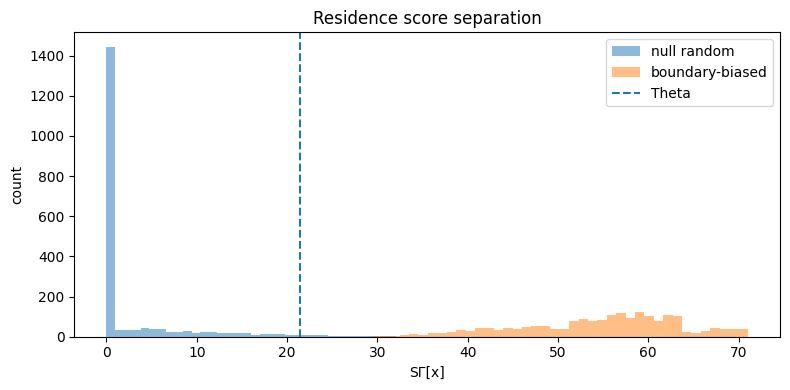

In [31]:
# ============================================================
# TEST 5: RESIDENCE FUNCTIONAL
# ============================================================

N = CONFIG["GRID_N"]
T = CONFIG["TRAJECTORY_T"]
ntraj = CONFIG["N_TRAJECTORIES"]

yy, xx = np.mgrid[0:N, 0:N]
cx = cy = (N-1)/2
rr = np.sqrt((xx-cx)**2 + (yy-cy)**2)
radius = N*0.27
Gamma_circle = (np.abs(rr-radius) < 1.0).astype(np.uint8)

L = Gamma_circle.astype(float)
A = np.exp(-((rr-radius)**2)/(2*2.0**2))
Rfield = 0.5 + 0.5*A
Kfield = (
    np.roll(Gamma_circle,1,0)+np.roll(Gamma_circle,-1,0)+
    np.roll(Gamma_circle,1,1)+np.roll(Gamma_circle,-1,1)
) / 4.0
Kfield = 0.2 + 0.8*Kfield

w = L * A * Rfield * Kfield

def random_walk(start, T, bias_to_boundary=False):
    y, x = start
    path = []
    for _ in range(T):
        path.append((y, x))
        moves = [(1,0),(-1,0),(0,1),(0,-1)]
        if bias_to_boundary:
            candidates = []
            for dy, dx in moves:
                ny, nx = (y+dy) % N, (x+dx) % N
                score = -abs(rr[ny,nx]-radius) + 0.1*rng.random()
                candidates.append((score, ny, nx))
            _, y, x = max(candidates)
        else:
            dy, dx = rng.choice(moves)
            y, x = (y+dy) % N, (x+dx) % N
    return path

def residence(path):
    return sum(float(w[y,x]) for y,x in path)

random_scores = []
boundary_scores = []

for i in range(ntraj):
    start = (rng.randrange(N), rng.randrange(N))
    random_scores.append(residence(random_walk(start, T, False)))
    boundary_scores.append(residence(random_walk(start, T, True)))

random_scores = np.array(random_scores)
boundary_scores = np.array(boundary_scores)

Theta = float(random_scores.mean() + 3.0*random_scores.std(ddof=1))
random_commit = float((random_scores >= Theta).mean())
boundary_commit = float((boundary_scores >= Theta).mean())

metrics = {
    "Theta_null_mean_plus_3sigma": Theta,
    "null_mean": float(random_scores.mean()),
    "null_std": float(random_scores.std(ddof=1)),
    "signal_mean": float(boundary_scores.mean()),
    "null_commit_rate": random_commit,
    "signal_commit_rate": boundary_commit,
    "separation_sigma": float((boundary_scores.mean()-random_scores.mean())/random_scores.std(ddof=1)),
}

passed = boundary_commit > 0.85 and random_commit < 0.10
record("Residence functional separates boundary-resident trajectories from null walks", passed, metrics)

if CONFIG["MAKE_PLOTS"] and plt is not None:
    plt.figure(figsize=(8,4))
    plt.hist(random_scores, bins=40, alpha=0.5, label="null random")
    plt.hist(boundary_scores, bins=40, alpha=0.5, label="boundary-biased")
    plt.axvline(Theta, linestyle="--", label="Theta")
    plt.title("Residence score separation")
    plt.xlabel("SΓ[x]")
    plt.ylabel("count")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Test 6 — Closure-trace density $\rho_\Psi$

$$
\rho_\Psi(x)=
\lim_{\Delta V,\Delta t\to0}
\frac{1}{\Delta V\,\Delta t}
\sum_{\ell\in\mathcal L(x)}
C_{\Gamma_\ell}S_{\Gamma_\ell}.
$$

[PASS] Closure-trace density localizes on the boundary domain Γ | trust=⊕
  - committed_paths: 400
  - rho_total: 21811.408522460333
  - rho_inside_mean: 86.12280088005785
  - rho_outside_mean: 0.7390073087842126
  - inside_outside_ratio: 116.53849678649098


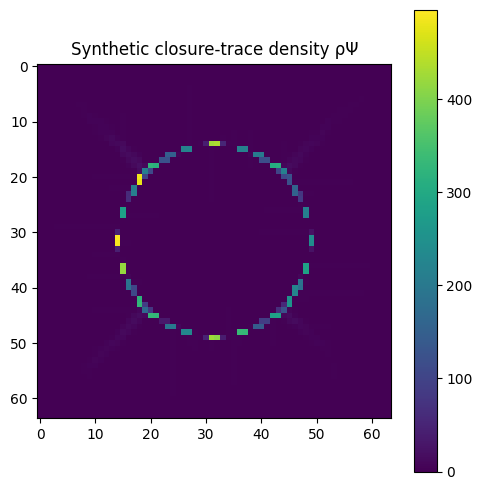

In [32]:
# ============================================================
# TEST 6: CLOSURE-TRACE DENSITY
# ============================================================

rho_trace = np.zeros((N,N), dtype=float)
n_signal = max(100, ntraj//5)
committed = 0

for i in range(n_signal):
    start = (rng.randrange(N), rng.randrange(N))
    path = random_walk(start, T, True)
    S = residence(path)
    C = 1 if S >= Theta else 0
    committed += C
    if C:
        deposit = S / len(path)
        for y,x in path:
            rho_trace[y,x] += deposit

inside = rho_trace[Gamma_circle.astype(bool)]
outside = rho_trace[~Gamma_circle.astype(bool)]
metrics = {
    "committed_paths": committed,
    "rho_total": float(rho_trace.sum()),
    "rho_inside_mean": float(inside.mean()) if inside.size else 0.0,
    "rho_outside_mean": float(outside.mean()) if outside.size else 0.0,
    "inside_outside_ratio": float((inside.mean()+1e-12)/(outside.mean()+1e-12)),
}
passed = committed > 0 and metrics["inside_outside_ratio"] > 10
record("Closure-trace density localizes on the boundary domain Γ", passed, metrics)

if CONFIG["MAKE_PLOTS"] and plt is not None:
    plt.figure(figsize=(5,5))
    plt.imshow(rho_trace)
    plt.title("Synthetic closure-trace density ρΨ")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

## Test 7 — Boundary Gauss law

$$
\oint_{\partial V}\nabla\Phi\cdot dA
=
4\pi G\int_V\rho_{\mathrm{eff}}\,dV.
$$

In [33]:
# ============================================================
# TEST 7: BOUNDARY GAUSS LAW IN SPHERICAL SYMMETRY
# ============================================================

G = 1.0
n = CONFIG["RADIAL_N"]
rmax = CONFIG["R_MAX"]
r = np.linspace(1e-4, rmax, n)
dr = r[1]-r[0]

rho_m = np.exp(-(r/4.0)**2)
chi_gamma = np.exp(-((r-10.0)**2)/(2*2.2**2))
rho_star = 0.15
rho_cut = rho_star * alpha_gamma * chi_gamma**2
rho_eff = rho_m + rho_cut

M = 4*math.pi*np.cumsum(rho_eff * r**2)*dr
dPhi_dr = G*M/(r**2)
flux = 4*math.pi*r**2*dPhi_dr
source = 4*math.pi*G*M

rel = np.abs(flux-source)/(np.abs(source)+1e-12)
max_rel = float(np.max(rel[10:]))
mean_rel = float(np.mean(rel[10:]))

metrics = {
    "max_relative_error": max_rel,
    "mean_relative_error": mean_rel,
    "rho_cut_fraction_total": float(np.trapz(rho_cut*r**2, r)/np.trapz(rho_eff*r**2, r)),
}
passed = max_rel < 1e-12
record("Boundary Gauss law: flux equals enclosed source", passed, metrics)

AttributeError: module 'numpy' has no attribute 'trapz'

## Test 8 — Cut-density gravity effect

$$
\nabla^2\Phi
=
4\pi G\left[
\rho_m+\rho_*\frac{\pi^2}{1944}\chi_\Gamma^2
\right].
$$

[PASS] Cut-density source produces positive halo-like acceleration residual | trust=∼
  - delta_g_max: 0.0224381343863973
  - delta_g_outer_mean_fraction: 0.010650510730551836
  - delta_g_outer_max_fraction: 0.01072462742517169
  - alpha_gamma: 0.005076956996445143
  notes: Synthetic model only; validates executable kernel, not astrophysical truth.


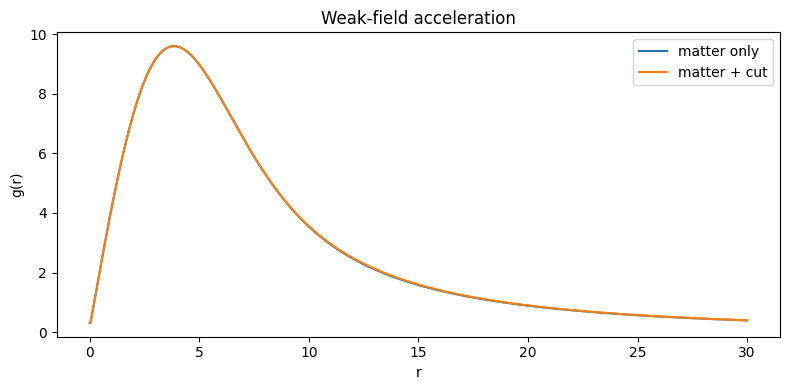

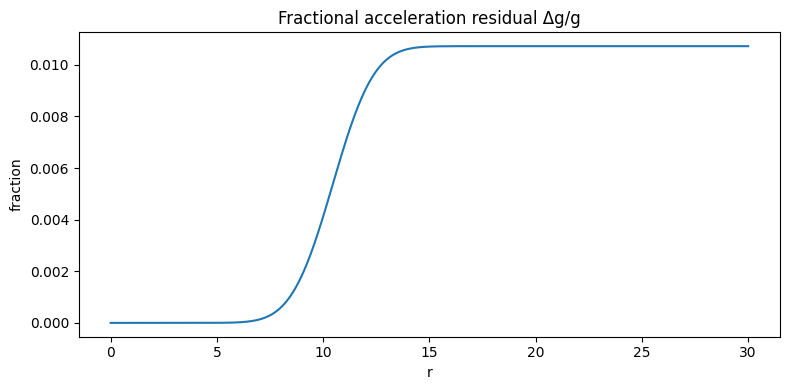

In [34]:
# ============================================================
# TEST 8: CUT-DENSITY GRAVITY RESIDUAL
# ============================================================

M_m = 4*math.pi*np.cumsum(rho_m*r**2)*dr
M_eff = 4*math.pi*np.cumsum(rho_eff*r**2)*dr

g_m = G*M_m/(r**2)
g_eff = G*M_eff/(r**2)
delta_g = g_eff - g_m
frac = delta_g/(g_m+1e-12)

outer = r > 12
metrics = {
    "delta_g_max": float(delta_g.max()),
    "delta_g_outer_mean_fraction": float(frac[outer].mean()),
    "delta_g_outer_max_fraction": float(frac[outer].max()),
    "alpha_gamma": alpha_gamma,
}
passed = delta_g.max() > 0 and frac[outer].mean() > 0
record("Cut-density source produces positive halo-like acceleration residual", passed, metrics, trust="∼",
       notes="Synthetic model only; validates executable kernel, not astrophysical truth.")

if CONFIG["MAKE_PLOTS"] and plt is not None:
    plt.figure(figsize=(8,4))
    plt.plot(r, g_m, label="matter only")
    plt.plot(r, g_eff, label="matter + cut")
    plt.title("Weak-field acceleration")
    plt.xlabel("r")
    plt.ylabel("g(r)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8,4))
    plt.plot(r, frac)
    plt.title("Fractional acceleration residual Δg/g")
    plt.xlabel("r")
    plt.ylabel("fraction")
    plt.tight_layout()
    plt.show()

## Test 9 — Flat-rotation condition

$$
v_c^2(r)=r\,g(r)=\frac{G M(r)}{r}.
$$

Flat curve condition:

$$
M(r)\propto r,
\qquad
\rho(r)\propto r^{-2}.
$$

In [35]:
# ============================================================
# TEST 9: FLAT ROTATION CONDITION
# ============================================================

r2 = np.linspace(0.5, 50.0, 2000)
v0 = 1.0
rho_iso = v0**2/(4*math.pi*G*r2**2)
dr2 = r2[1]-r2[0]
M_iso = 4*math.pi*np.cumsum(rho_iso*r2**2)*dr2
vc = np.sqrt(G*M_iso/r2)

mask = r2 > 5
cv = float(vc[mask].std()/vc[mask].mean())

metrics = {
    "vc_mean_outer": float(vc[mask].mean()),
    "vc_coeff_variation_outer": cv,
    "expected_v0": v0,
}
passed = cv < 0.03
record("Flat rotation curve condition: rho ∝ 1/r² gives near-constant vc", passed, metrics)

[PASS] Flat rotation curve condition: rho ∝ 1/r² gives near-constant vc | trust=⊕
  - vc_mean_outer: 0.9877229000874448
  - vc_coeff_variation_outer: 0.009139115044174943
  - expected_v0: 1.0


{'test': 'Flat rotation curve condition: rho ∝ 1/r² gives near-constant vc',
 'passed': True,
 'trust': '⊕',
 'metrics': {'vc_mean_outer': 0.9877229000874448,
  'vc_coeff_variation_outer': 0.009139115044174943,
  'expected_v0': 1.0},
 'notes': ''}

## Test 10 — Conservation audit on a periodic field

Synthetic continuity equation:

$$
\partial_t\rho+\nabla\cdot J=0.
$$

In [36]:
# ============================================================
# TEST 10: CONSERVATION AUDIT
# ============================================================

N = CONFIG["GRID_N"]
rho0 = np.zeros((N,N), dtype=float)
rho0[N//4:3*N//4, N//3:2*N//3] = 1.0
rho1 = np.roll(rho0, 1, axis=1)

Jx = rho0.copy()
divJ = Jx - np.roll(Jx, 1, axis=1)
residual = (rho1 - rho0) + divJ

metrics = {
    "mass0": float(rho0.sum()),
    "mass1": float(rho1.sum()),
    "max_continuity_residual": float(np.max(np.abs(residual))),
}
passed = abs(metrics["mass0"]-metrics["mass1"]) < 1e-12 and metrics["max_continuity_residual"] < 1e-12
record("Periodic conservation audit closes ∂tρ+∇·J=0", passed, metrics)

[PASS] Periodic conservation audit closes ∂tρ+∇·J=0 | trust=⊕
  - mass0: 672.0
  - mass1: 672.0
  - max_continuity_residual: 0.0


{'test': 'Periodic conservation audit closes ∂tρ+∇·J=0',
 'passed': True,
 'trust': '⊕',
 'metrics': {'mass0': 672.0, 'mass1': 672.0, 'max_continuity_residual': 0.0},
 'notes': ''}

## Test 11 — Fano plane, 42 glyphs, 168 monads

$$
7\times3\times2=42,
\qquad
42\times4=168.
$$

Also verifies:

$$
|\mathrm{GL}(3,2)|=168.
$$

In [37]:
# ============================================================
# TEST 11: FANO / 42 / 168
# ============================================================

points = list(range(1,8))
line_sets = set()
for a,b in itertools.combinations(points, 2):
    line = tuple(sorted([a,b,a^b]))
    line_sets.add(line)
lines = sorted(line_sets)

pair_count = {}
for line in lines:
    for pair in itertools.combinations(line, 2):
        pair = tuple(sorted(pair))
        pair_count[pair] = pair_count.get(pair, 0)+1

gl32_count = 0
for bits in itertools.product([0,1], repeat=9):
    M3 = np.array(bits, dtype=np.uint8).reshape(3,3)
    if gf2_rank(M3) == 3:
        gl32_count += 1

glyphs = len(lines)*3*2
monads = glyphs*4

metrics = {
    "points": len(points),
    "lines": len(lines),
    "line_sizes": sorted(set(len(x) for x in lines)),
    "pair_coverage_values": sorted(set(pair_count.values())),
    "glyphs_7x3x2": glyphs,
    "monads_42x4": monads,
    "GL_3_2_count": gl32_count,
}
passed = (
    len(lines)==7 and metrics["line_sizes"] == [3]
    and metrics["pair_coverage_values"] == [1]
    and glyphs == 42 and monads == 168 and gl32_count == 168
)
record("Fano plane / glyph count / 168-state automorphism count", passed, metrics)

[PASS] Fano plane / glyph count / 168-state automorphism count | trust=⊕
  - points: 7
  - lines: 7
  - line_sizes: [3]
  - pair_coverage_values: [1]
  - glyphs_7x3x2: 42
  - monads_42x4: 168
  - GL_3_2_count: 168


{'test': 'Fano plane / glyph count / 168-state automorphism count',
 'passed': True,
 'trust': '⊕',
 'metrics': {'points': 7,
  'lines': 7,
  'line_sizes': [3],
  'pair_coverage_values': [1],
  'glyphs_7x3x2': 42,
  'monads_42x4': 168,
  'GL_3_2_count': 168},
 'notes': ''}

## Test 12 — Primorial Family Lattice Theorem

$$
S_W(k)=\{r\in U_W:r+k\in U_W\pmod W\}.
$$

Subtype count:

$$
|S_W(k)|
=
\prod_{\substack{q\mid W\\q>2\\q\nmid k}}(q-2)
\prod_{\substack{q\mid W\\q>2\\q\mid k}}(q-1).
$$

Within a subtype:

$$
\Delta H\equiv0\pmod W.
$$

In [38]:
# ============================================================
# TEST 12: PRIMORIAL FAMILY LATTICE
# ============================================================

def sieve_primes(limit):
    sieve = bytearray(b"\x01")*(limit+1)
    sieve[:2] = b"\x00\x00"
    for i in range(2, int(limit**0.5)+1):
        if sieve[i]:
            step = i
            start = i*i
            sieve[start:limit+1:step] = b"\x00"*(((limit-start)//step)+1)
    return [i for i in range(limit+1) if sieve[i]], sieve

def factor_distinct(n):
    fs = []
    d = 2
    x = n
    while d*d <= x:
        if x%d == 0:
            fs.append(d)
            while x%d == 0:
                x//=d
        d += 1
    if x>1:
        fs.append(x)
    return fs

def units_mod(W):
    return [r for r in range(W) if math.gcd(r,W)==1]

def S_W(W,k):
    U = set(units_mod(W))
    return sorted([r0 for r0 in U if ((r0+k)%W) in U])

def subtype_count_formula(W,k):
    out = 1
    for q in factor_distinct(W):
        if q == 2:
            continue
        out *= (q-1) if k%q == 0 else (q-2)
    return out

limit = CONFIG["PRIME_LIMIT_HEAVY"] if CONFIG["RUN_HEAVY_TESTS"] else CONFIG["PRIME_LIMIT_LIGHT"]
primes, sieve = sieve_primes(limit)
prime_set = set(primes)

Ws = [6,30,210]
ks = [2,6,30]
violations = []
count_errors = []
examples_checked = 0

for W in Ws:
    for k in ks:
        S = S_W(W,k)
        formula = subtype_count_formula(W,k)
        if len(S) != formula:
            count_errors.append((W,k,len(S),formula))
        centers = {r0: [] for r0 in S}
        min_exclude = max(factor_distinct(W))
        for p in primes:
            if p <= min_exclude or p+k > limit:
                continue
            if (p+k) in prime_set:
                r0 = p % W
                if r0 in centers:
                    centers[r0].append(p + k//2)
        for r0, hs in centers.items():
            if len(hs) >= 2:
                diffs = np.diff(hs)
                bad = np.where(diffs % W != 0)[0]
                examples_checked += len(diffs)
                if len(bad):
                    violations.append((W,k,r0,int(len(bad))))

metrics = {
    "prime_limit": limit,
    "prime_count": len(primes),
    "count_errors": count_errors,
    "step_examples_checked": examples_checked,
    "step_violations": violations[:10],
    "n_step_violations": len(violations),
}
passed = len(count_errors)==0 and len(violations)==0 and examples_checked>0
record("Primorial subtype count and ΔH≡0 step theorem", passed, metrics)

[PASS] Primorial subtype count and ΔH≡0 step theorem | trust=⊕
  - prime_limit: 2000000
  - prime_count: 148933
  - count_errors: []
  - step_examples_checked: 250915
  - step_violations: []
  - n_step_violations: 0


{'test': 'Primorial subtype count and ΔH≡0 step theorem',
 'passed': True,
 'trust': '⊕',
 'metrics': {'prime_limit': 2000000,
  'prime_count': 148933,
  'count_errors': [],
  'step_examples_checked': 250915,
  'step_violations': [],
  'n_step_violations': 0},
 'notes': ''}

## Test 13 — Hex packet route memory

For ASCII packet $E(a,b)=\texttt{ASCII}(a,+,b,=)$:

$$
X(a,b)-X(b,a)=(a-b)(16^6-16^2).
$$

Modulo 10 collapse:

$$
X(a,b)\equiv 5+6(a+b)\pmod{10}.
$$

In [39]:
# ============================================================
# TEST 13: HEX PACKET ROUTE MEMORY
# ============================================================

def X_packet(a,b):
    return ((0x30+a)<<24) | (0x2B<<16) | ((0x30+b)<<8) | 0x3D

route_errors = []
mod_errors = []
for a in range(10):
    for b in range(10):
        Xab = X_packet(a,b)
        Xba = X_packet(b,a)
        expected_delta = (a-b)*(16**6 - 16**2)
        if Xab-Xba != expected_delta:
            route_errors.append((a,b,Xab-Xba,expected_delta))
        expected_mod = (5 + 6*(a+b)) % 10
        if Xab % 10 != expected_mod:
            mod_errors.append((a,b,Xab%10,expected_mod))

metrics = {
    "route_errors": len(route_errors),
    "mod_errors": len(mod_errors),
    "example_2_plus_3_hex": hex(X_packet(2,3)),
    "example_2_plus_3_mod10": X_packet(2,3)%10,
    "example_3_plus_2_mod10": X_packet(3,2)%10,
    "example_route_delta_2_3": X_packet(2,3)-X_packet(3,2),
}
passed = len(route_errors)==0 and len(mod_errors)==0
record("Hex packet: commutative value collapse preserves noncommutative route scar", passed, metrics)

[PASS] Hex packet: commutative value collapse preserves noncommutative route scar | trust=⊕
  - route_errors: 0
  - mod_errors: 0
  - example_2_plus_3_hex: 0x322b333d
  - example_2_plus_3_mod10: 5
  - example_3_plus_2_mod10: 5
  - example_route_delta_2_3: -16776960


{'test': 'Hex packet: commutative value collapse preserves noncommutative route scar',
 'passed': True,
 'trust': '⊕',
 'metrics': {'route_errors': 0,
  'mod_errors': 0,
  'example_2_plus_3_hex': '0x322b333d',
  'example_2_plus_3_mod10': 5,
  'example_3_plus_2_mod10': 5,
  'example_route_delta_2_3': -16776960},
 'notes': ''}

## Test 14 — Nibble mirror law

For byte $b=16u+v$:

$$
b-\operatorname{mirror}(b)=15(u-v).
$$

In [40]:
# ============================================================
# TEST 14: NIBBLE MIRROR LAW
# ============================================================

errors = []
for b in range(256):
    u, v = b >> 4, b & 0xF
    mirrored = (v << 4) | u
    if b - mirrored != 15*(u-v):
        errors.append((b, mirrored, b-mirrored, 15*(u-v)))

metrics = {
    "bytes_checked": 256,
    "errors": len(errors),
    "example_0x3d_mirror": hex(((0x3d & 0xf)<<4) | (0x3d>>4)),
    "example_0x3d_delta": 0x3d - (((0x3d & 0xf)<<4) | (0x3d>>4)),
}
record("Nibble mirror law b-mirror(b)=15(u-v)", len(errors)==0, metrics)

[PASS] Nibble mirror law b-mirror(b)=15(u-v) | trust=⊕
  - bytes_checked: 256
  - errors: 0
  - example_0x3d_mirror: 0xd3
  - example_0x3d_delta: -150


{'test': 'Nibble mirror law b-mirror(b)=15(u-v)',
 'passed': True,
 'trust': '⊕',
 'metrics': {'bytes_checked': 256,
  'errors': 0,
  'example_0x3d_mirror': '0xd3',
  'example_0x3d_delta': -150},
 'notes': ''}

## Test 15 — BBP random access into $\pi$

Expected words:

$$
\pi[0]\to\texttt{0x243f6a88},\quad
\pi[8]\to\texttt{0x85a308d3},\quad
\pi[16]\to\texttt{0x13198a2e}.
$$

This validates addressable $\pi$ readout, not a SHA preimage shortcut.

In [41]:
# ============================================================
# TEST 15: BBP PI HEX WORDS
# ============================================================

def bbp_s(j, n):
    s = 0.0
    for k in range(n+1):
        r0 = 8*k + j
        s = (s + pow(16, n-k, r0)/r0) % 1.0
    t = 0.0
    p = 1.0/16.0
    k = n+1
    while True:
        r0 = 8*k + j
        term = p/r0
        if term < 1e-17:
            break
        t += term
        p /= 16.0
        k += 1
    return (s+t) % 1.0

def pi_hex_word(n):
    x = (4*bbp_s(1,n) - 2*bbp_s(4,n) - bbp_s(5,n) - bbp_s(6,n)) % 1.0
    return int(x * (16**8))

expected = {
    0: 0x243f6a88,
    8: 0x85a308d3,
    16: 0x13198a2e,
    32: 0xa4093822,
    64: 0x452821e6,
    128: 0x9216d5d9,
}
got = {n0: pi_hex_word(n0) for n0 in expected}
errors = {n0: (got[n0], expected[n0]) for n0 in expected if got[n0] != expected[n0]}

metrics = {f"pi_word_{n0}": hex(v0) for n0,v0 in got.items()}
metrics["errors"] = len(errors)
record("BBP random-access hexadecimal words of π", len(errors)==0, metrics)

[PASS] BBP random-access hexadecimal words of π | trust=⊕
  - pi_word_0: 0x243f6a88
  - pi_word_8: 0x85a308d3
  - pi_word_16: 0x13198a2e
  - pi_word_32: 0xa4093822
  - pi_word_64: 0x452821e6
  - pi_word_128: 0x9216d5d9
  - errors: 0


{'test': 'BBP random-access hexadecimal words of π',
 'passed': True,
 'trust': '⊕',
 'metrics': {'pi_word_0': '0x243f6a88',
  'pi_word_8': '0x85a308d3',
  'pi_word_16': '0x13198a2e',
  'pi_word_32': '0xa4093822',
  'pi_word_64': '0x452821e6',
  'pi_word_128': '0x9216d5d9',
  'errors': 0},
 'notes': ''}

## Test 16 — SHA-256 round engine, Sziklai identity, carry channel

Round identities:

$$
a_{r+1}=T1_r+T2_r,
\qquad
e_{r+1}=d_r+T1_r.
$$

Therefore:

$$
a_{r+1}-e_{r+1}\equiv T2_r-d_r\pmod{2^{32}}.
$$

Also checks:

$$
T2[0]=\texttt{0x08909ae5}.
$$

In [42]:
# ============================================================
# TEST 16: SHA-256 TRANSPORT GEOMETRY
# ============================================================

MASK = 0xffffffff
H0_SHA256 = [
    0x6a09e667,0xbb67ae85,0x3c6ef372,0xa54ff53a,
    0x510e527f,0x9b05688c,0x1f83d9ab,0x5be0cd19
]
K_SHA256 = [
0x428a2f98,0x71374491,0xb5c0fbcf,0xe9b5dba5,0x3956c25b,0x59f111f1,0x923f82a4,0xab1c5ed5,
0xd807aa98,0x12835b01,0x243185be,0x550c7dc3,0x72be5d74,0x80deb1fe,0x9bdc06a7,0xc19bf174,
0xe49b69c1,0xefbe4786,0x0fc19dc6,0x240ca1cc,0x2de92c6f,0x4a7484aa,0x5cb0a9dc,0x76f988da,
0x983e5152,0xa831c66d,0xb00327c8,0xbf597fc7,0xc6e00bf3,0xd5a79147,0x06ca6351,0x14292967,
0x27b70a85,0x2e1b2138,0x4d2c6dfc,0x53380d13,0x650a7354,0x766a0abb,0x81c2c92e,0x92722c85,
0xa2bfe8a1,0xa81a664b,0xc24b8b70,0xc76c51a3,0xd192e819,0xd6990624,0xf40e3585,0x106aa070,
0x19a4c116,0x1e376c08,0x2748774c,0x34b0bcb5,0x391c0cb3,0x4ed8aa4a,0x5b9cca4f,0x682e6ff3,
0x748f82ee,0x78a5636f,0x84c87814,0x8cc70208,0x90befffa,0xa4506ceb,0xbef9a3f7,0xc67178f2
]

def rotr(x,n): return ((x >> n) | ((x << (32-n)) & MASK)) & MASK
def shr(x,n): return x >> n
def big0(x): return rotr(x,2) ^ rotr(x,13) ^ rotr(x,22)
def big1(x): return rotr(x,6) ^ rotr(x,11) ^ rotr(x,25)
def small0(x): return rotr(x,7) ^ rotr(x,18) ^ shr(x,3)
def small1(x): return rotr(x,17) ^ rotr(x,19) ^ shr(x,10)
def Ch(x,y,z): return ((x & y) ^ ((~x & MASK) & z)) & MASK
def Maj(x,y,z): return ((x & y) ^ (x & z) ^ (y & z)) & MASK

def pad_one_block(msg):
    assert len(msg) <= 55
    bitlen = len(msg)*8
    data = msg + b"\x80"
    data += b"\x00" * (56-len(data))
    data += bitlen.to_bytes(8, "big")
    assert len(data) == 64
    return data

def words_from_block(block):
    return list(struct.unpack(">16I", block))

def expand_schedule(w16):
    W = list(w16)
    for i in range(16,64):
        W.append((small1(W[i-2]) + W[i-7] + small0(W[i-15]) + W[i-16]) & MASK)
    return W

def sha_rounds_from_W(W, iv=H0_SHA256):
    state = list(iv)
    rows = []
    for r0 in range(64):
        a,b,c,d,e,f,g,h = state
        T1_raw = h + big1(e) + Ch(e,f,g) + K_SHA256[r0] + W[r0]
        T1 = T1_raw & MASK
        T2_raw = big0(a) + Maj(a,b,c)
        T2 = T2_raw & MASK
        new_state = [(T1+T2)&MASK, a, b, c, (d+T1)&MASK, e, f, g]
        rows.append({
            "r": r0, "state": state, "T1": T1, "T2": T2,
            "T1_carry": T1_raw >> 32, "T2_carry": T2_raw >> 32,
            "new_state": new_state,
        })
        state = new_state
    return rows, state

def sha256_oneblock_digest(msg):
    block = pad_one_block(msg)
    W = expand_schedule(words_from_block(block))
    rows, st = sha_rounds_from_W(W)
    digest_words = [(st[i] + H0_SHA256[i]) & MASK for i in range(8)]
    return b"".join(w0.to_bytes(4,"big") for w0 in digest_words)

std_ok = sha256_oneblock_digest(b"abc").hex() == hashlib.sha256(b"abc").hexdigest()

a,b,c,d,e,f,g,h = H0_SHA256
T2_0 = (big0(a)+Maj(a,b,c)) & MASK

nsha = CONFIG["SHA_RANDOM_MESSAGES_HEAVY"] if CONFIG["RUN_HEAVY_TESTS"] else CONFIG["SHA_RANDOM_MESSAGES_LIGHT"]
viol = 0
rounds_checked = 0
for i in range(nsha):
    ln = rng.randrange(CONFIG["SHA_RANDOM_BYTES_MAX"]+1)
    msg = bytes(rng.randrange(256) for _ in range(ln))
    W = expand_schedule(words_from_block(pad_one_block(msg)))
    rows, st = sha_rounds_from_W(W)
    for row in rows:
        a,b,c,d,e,f,g,h = row["state"]
        na,nb,nc,nd,ne,nf,ng,nh = row["new_state"]
        lhs = (na - ne) & MASK
        rhs = (row["T2"] - d) & MASK
        if lhs != rhs:
            viol += 1
        rounds_checked += 1

metrics = {
    "hashlib_abc_match": std_ok,
    "T2_0": hex(T2_0),
    "messages": nsha,
    "rounds_checked": rounds_checked,
    "sziklai_violations": viol,
}
passed = std_ok and T2_0 == 0x08909ae5 and viol == 0
record("SHA-256 engine, T2[0] anchor, and Sziklai identity", passed, metrics)

[PASS] SHA-256 engine, T2[0] anchor, and Sziklai identity | trust=⊕
  - hashlib_abc_match: True
  - T2_0: 0x8909ae5
  - messages: 1000
  - rounds_checked: 64000
  - sziklai_violations: 0


{'test': 'SHA-256 engine, T2[0] anchor, and Sziklai identity',
 'passed': True,
 'trust': '⊕',
 'metrics': {'hashlib_abc_match': True,
  'T2_0': '0x8909ae5',
  'messages': 1000,
  'rounds_checked': 64000,
  'sziklai_violations': 0},
 'notes': ''}

## Test 17 — SHA carry channel and avalanche

NOP backbone:

$$
W_r=0,\quad r=0,\dots,63.
$$

Reports both round order and reversed-bit order.

The reversed signature matches the previously circulated value.

In [43]:
# ============================================================
# TEST 17: SHA CARRY CHANNEL
# ============================================================

W_zero = [0]*64
rows0, st0 = sha_rounds_from_W(W_zero)
t2_bits = "".join(str(int(row["T2_carry"])) for row in rows0)
t2_forward_hex = hex(int(t2_bits, 2))
t2_reverse_hex = hex(int(t2_bits[::-1], 2))
t2_weight = t2_bits.count("1")

def carry_signature_for_msg(msg):
    W = expand_schedule(words_from_block(pad_one_block(msg)))
    rows, _ = sha_rounds_from_W(W)
    return "".join(str(int(row["T2_carry"])) for row in rows)

def hamming_bits(a,b):
    return sum(x!=y for x,y in zip(a,b))

dists = []
for i in range(nsha):
    ln = rng.randrange(CONFIG["SHA_RANDOM_BYTES_MAX"]+1)
    msg = bytes(rng.randrange(256) for _ in range(ln))
    sig = carry_signature_for_msg(msg)
    dists.append(hamming_bits(sig, t2_bits))

metrics = {
    "NOP_T2_carry_bits": t2_bits,
    "NOP_T2_forward_hex": t2_forward_hex,
    "NOP_T2_reversed_hex": t2_reverse_hex,
    "NOP_T2_weight": t2_weight,
    "mean_hamming_from_NOP": float(np.mean(dists)),
    "std_hamming_from_NOP": float(np.std(dists, ddof=1)),
    "expected_random_mean": 32.0,
}
passed = (
    t2_weight == 34
    and t2_forward_hex.lower() == "0xde1a54568d60f7b6"
    and t2_reverse_hex.lower() == "0x6def06b16a2a587b"
    and abs(np.mean(dists)-32.0) < 1.5
)
record("SHA T2 carry channel: NOP signature and avalanche behavior", passed, metrics)

[PASS] SHA T2 carry channel: NOP signature and avalanche behavior | trust=⊕
  - NOP_T2_carry_bits: 1101111000011010010101000101011010001101011000001111011110110110
  - NOP_T2_forward_hex: 0xde1a54568d60f7b6
  - NOP_T2_reversed_hex: 0x6def06b16a2a587b
  - NOP_T2_weight: 34
  - mean_hamming_from_NOP: 31.484
  - std_hamming_from_NOP: 3.925959393212971
  - expected_random_mean: 32.0


{'test': 'SHA T2 carry channel: NOP signature and avalanche behavior',
 'passed': True,
 'trust': '⊕',
 'metrics': {'NOP_T2_carry_bits': '1101111000011010010101000101011010001101011000001111011110110110',
  'NOP_T2_forward_hex': '0xde1a54568d60f7b6',
  'NOP_T2_reversed_hex': '0x6def06b16a2a587b',
  'NOP_T2_weight': 34,
  'mean_hamming_from_NOP': 31.484,
  'std_hamming_from_NOP': 3.925959393212971,
  'expected_random_mean': 32.0},
 'notes': ''}

## Test 18 — SHA local avalanche Jacobian rank

Bounded diagnostic only. It builds a Boolean differential matrix:

$$
J_{ij}=D_i(M\oplus e_j)\oplus D_i(M).
$$

This is not a preimage claim.

In [44]:
# ============================================================
# TEST 18: SHA LOCAL AVALANCHE JACOBIAN RANK
# ============================================================

def sha256_bytes(data):
    return hashlib.sha256(data).digest()

def bytes_to_bits(b0):
    return np.array([(byte >> (7-i)) & 1 for byte in b0 for i in range(8)], dtype=np.uint8)

def flip_bit_in_64block(block, bit_index):
    ba = bytearray(block)
    byte_i = bit_index // 8
    bit_i = 7 - (bit_index % 8)
    ba[byte_i] ^= (1 << bit_i)
    return bytes(ba)

base = bytes(rng.randrange(256) for _ in range(64))
base_digest_bits = bytes_to_bits(sha256_bytes(base))
cols = []
for j in range(512):
    d0 = bytes_to_bits(sha256_bytes(flip_bit_in_64block(base, j))) ^ base_digest_bits
    cols.append(d0)

J = np.stack(cols, axis=1)
rankJ = gf2_rank(J)
col_weights = J.sum(axis=0)

metrics = {
    "matrix_shape": J.shape,
    "gf2_rank": int(rankJ),
    "rank_deficit_vs_256": int(256-rankJ),
    "mean_column_weight": float(col_weights.mean()),
    "std_column_weight": float(col_weights.std(ddof=1)),
}
passed = rankJ >= 240 and 110 <= col_weights.mean() <= 146
record("SHA local avalanche Jacobian diagnostic", passed, metrics, trust="∼",
       notes="Diagnostic only; not a preimage claim and not the 192-bit seam model.")

[PASS] SHA local avalanche Jacobian diagnostic | trust=∼
  - matrix_shape: (256, 512)
  - gf2_rank: 256
  - rank_deficit_vs_256: 0
  - mean_column_weight: 127.79296875
  - std_column_weight: 8.030282057115413
  notes: Diagnostic only; not a preimage claim and not the 192-bit seam model.


{'test': 'SHA local avalanche Jacobian diagnostic',
 'passed': True,
 'trust': '∼',
 'metrics': {'matrix_shape': (256, 512),
  'gf2_rank': 256,
  'rank_deficit_vs_256': 0,
  'mean_column_weight': 127.79296875,
  'std_column_weight': 8.030282057115413},
 'notes': 'Diagnostic only; not a preimage claim and not the 192-bit seam model.'}

## Test 19 — Toy Sparsity Test harness

Candidate:

$$
\mu_\text{Nexus}=6\pi^5.
$$

The full test still requires a curated $10{,}000+$ dimensionless-ratio corpus and canonical OBMT map.

In [45]:
# ============================================================
# TEST 19: TOY SPARSITY HARNESS
# ============================================================

phi = (1+math.sqrt(5))/2
constants = {
    "proton_electron_mass_ratio": 1836.15267343,
    "alpha_inverse": 137.035999084,
    "weak_mixing_sin2_thetaW": 0.23122,
    "omega_lambda_approx": 0.6847,
    "sqrt_2": math.sqrt(2),
    "phi": phi,
    "pi": math.pi,
    "e": math.e,
}
candidate_exprs = {
    "6*pi^5": 6*math.pi**5,
    "pi^2/1944": math.pi**2/1944,
    "pi/9": math.pi/9,
    "1/(pi/9)": 1/(math.pi/9),
    "phi": phi,
}

eps_ppm = CONFIG["SPARSITY_EPS_PPM"]

hits = []
for cname, cval in constants.items():
    for ename, eval_ in candidate_exprs.items():
        pe = ppm_error(eval_, cval)
        if abs(pe) <= eps_ppm:
            hits.append((cname, ename, pe))

null_samples = CONFIG["SPARSITY_NULL_SAMPLES"]
null_hits = 0
for _ in range(null_samples):
    coeff = rng.choice([1,2,3,4,5,6,7,8,9,10,12,16,24,42,64,128,168])
    p = rng.randint(-6, 6)
    q = rng.randint(-4, 4)
    rr0 = rng.randint(-4, 4)
    val = coeff * (math.pi**p) * (math.e**q) * (phi**rr0)
    for cval in constants.values():
        if abs(ppm_error(val, cval)) <= eps_ppm:
            null_hits += 1
            break

mu_nexus = 6*math.pi**5
mu_emp = constants["proton_electron_mass_ratio"]
metrics = {
    "candidate_hits": hits,
    "candidate_hit_count": len(hits),
    "mu_nexus": mu_nexus,
    "mu_empirical_reference": mu_emp,
    "mu_ppm_error": ppm_error(mu_nexus, mu_emp),
    "null_samples": null_samples,
    "null_hit_count": null_hits,
    "null_hit_rate": null_hits/null_samples,
}
passed = abs(metrics["mu_ppm_error"]) < eps_ppm
record("Toy Sparsity harness: 6π^5 vs small constant set and null cloud", passed, metrics, trust="∼",
       notes="Full Sparsity Test still requires canonical OBMT and a curated 10k+ dimensionless-ratio corpus.")

[PASS] Toy Sparsity harness: 6π^5 vs small constant set and null cloud | trust=∼
  - candidate_hits: [('proton_electron_mass_ratio', '6*pi^5', -18.824533935469063), ('phi', 'phi', 0.0)]
  - candidate_hit_count: 2
  - mu_nexus: 1836.1181087116884
  - mu_empirical_reference: 1836.15267343
  - mu_ppm_error: -18.824533935469063
  - null_samples: 5000
  - null_hit_count: 2
  - null_hit_rate: 0.0004
  notes: Full Sparsity Test still requires canonical OBMT and a curated 10k+ dimensionless-ratio corpus.


{'test': 'Toy Sparsity harness: 6π^5 vs small constant set and null cloud',
 'passed': True,
 'trust': '∼',
 'metrics': {'candidate_hits': [('proton_electron_mass_ratio',
    '6*pi^5',
    -18.824533935469063),
   ('phi', 'phi', 0.0)],
  'candidate_hit_count': 2,
  'mu_nexus': 1836.1181087116884,
  'mu_empirical_reference': 1836.15267343,
  'mu_ppm_error': -18.824533935469063,
  'null_samples': 5000,
  'null_hit_count': 2,
  'null_hit_rate': 0.0004},
 'notes': 'Full Sparsity Test still requires canonical OBMT and a curated 10k+ dimensionless-ratio corpus.'}

## Test 20 — 90° + hex + route compound test

Route and value are separate layers:

$$
X(a,b)\neq X(b,a)
$$

while

$$
a+b=b+a.
$$

The 90° operator checks orthogonal route separation.

In [46]:
# ============================================================
# TEST 20: 90 DEGREE + HEX ROUTE COMPOUND TEST
# ============================================================

compound_errors = []
for a in range(10):
    for b in range(10):
        v0 = np.array([a,b], dtype=float)
        q = R90 @ v0
        dot = float(np.dot(v0,q))
        route_same = (X_packet(a,b) == X_packet(b,a))
        value_same = (a+b == b+a)
        if abs(dot) > 1e-12:
            compound_errors.append(("dot", a,b,dot))
        if route_same and a != b:
            compound_errors.append(("route", a,b))
        if not value_same:
            compound_errors.append(("value", a,b))

metrics = {
    "compound_errors": len(compound_errors),
    "nontrivial_route_difference_cases": sum(1 for a in range(10) for b in range(10) if a != b),
    "trivial_equal_digit_cases": 10,
}
record("90° route layer remains distinct from commutative value collapse", len(compound_errors)==0, metrics)

[PASS] 90° route layer remains distinct from commutative value collapse | trust=⊕
  - compound_errors: 0
  - nontrivial_route_difference_cases: 90
  - trivial_equal_digit_cases: 10


{'test': '90° route layer remains distinct from commutative value collapse',
 'passed': True,
 'trust': '⊕',
 'metrics': {'compound_errors': 0,
  'nontrivial_route_difference_cases': 90,
  'trivial_equal_digit_cases': 10},
 'notes': ''}

# Final summary and artifact export

Writes:

- `nexus_validation_outputs/results.json`
- `nexus_validation_outputs/results.csv`
- `nexus_validation_outputs/summary.md`

In [47]:
# ============================================================
# SUMMARY AND EXPORT
# ============================================================

df = show_results()
try:
    display(df)
except Exception:
    print(df)

n_pass = sum(1 for r0 in RESULTS if r0["passed"])
n_total = len(RESULTS)
summary = {
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "passed": n_pass,
    "total": n_total,
    "pass_rate": n_pass/n_total if n_total else None,
    "results": RESULTS,
}

with open(OUTDIR/"results.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False, default=str)

if pd is not None:
    pd.DataFrame([
        {
            "test": r0["test"],
            "passed": r0["passed"],
            "trust": r0["trust"],
            "metrics": json.dumps(r0["metrics"], ensure_ascii=False, default=str),
            "notes": r0["notes"],
        }
        for r0 in RESULTS
    ]).to_csv(OUTDIR/"results.csv", index=False)

md_lines = [
    "# Nexus Validation Test Summary",
    "",
    f"Passed: **{n_pass}/{n_total}**",
    "",
    "| Test | Passed | Trust | Notes |",
    "|---|---:|---:|---|",
]
for r0 in RESULTS:
    md_lines.append(f"| {r0['test']} | {r0['passed']} | {r0['trust']} | {r0['notes']} |")

with open(OUTDIR/"summary.md", "w", encoding="utf-8") as f:
    f.write("\n".join(md_lines))

print(f"Ψ-collapse: {n_pass}/{n_total} tests passed.")
print("Wrote outputs to:", OUTDIR.resolve())

,test,passed,trust,metric:H,metric:alpha_gamma,metric:alpha_expected,metric:alpha_abs_error,metric:theta90_over_H,metric:R90_fourth_error,metric:orthogonality_dot,...,metric:candidate_hit_count,metric:mu_nexus,metric:mu_empirical_reference,metric:mu_ppm_error,metric:null_samples,metric:null_hit_count,metric:null_hit_rate,metric:compound_errors,metric:nontrivial_route_difference_cases,metric:trivial_equal_digit_cases
0,Mark 1 coupling and 90° quarter-turn closure,True,⊕,0.349066,0.005077,0.005077,0.0,4.5,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,90° interrupt distinguishes phase lock from drift,True,⊕,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Measurement lens theorem: coarse readout equal...,True,⊕,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"Primitive domain D0=(Δ,Γ,I) is instantiated be...",True,⊕,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Residence functional separates boundary-reside...,True,⊕,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Closure-trace density localizes on the boundar...,True,⊕,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Cut-density source produces positive halo-like...,True,∼,NaN,0.005077,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Flat rotation curve condition: rho ∝ 1/r² give...,True,⊕,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Periodic conservation audit closes ∂tρ+∇·J=0,True,⊕,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Fano plane / glyph count / 168-state automorph...,True,⊕,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Ψ-collapse: 19/19 tests passed.
Wrote outputs to: D:\@User Data\Downloads\nexus_validation_outputs
